SHAP analysis on trained CNNs using DeepSHAP (GradientExplainer).

For image models, SHAP produces a saliency map: which pixels/voxels
contributed most to the PD vs HC prediction. This tells you and your
tutor whether the model is attending to the striatum (correct) or
something else like skull or background (confound).

For 2D/2.5D models this produces a 2D heatmap per image.
For 3D models it produces a 3D volume (I'll try to visualise as slices).

Output: analysis/outputs/shap/
  shap_mean_heatmap.svg      ;; average SHAP across test patients
  shap_examples_PD.svg       ;; SHAP for a few PD patients
  shap_examples_HC.svg       ;; SHAP for a few HC patients

In [1]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from torch.utils.data import DataLoader
from monai.data import Dataset as MonaiDataset
from sklearn.model_selection import train_test_split


sys.path.insert(0, os.path.abspath('/home/akarel/src_tfg'))
from src.architectures import ParkinsonClassifier25D, ParkinsonClassifier3D_deeper
from src.transforms import get_25d_transforms_padding, get_3d_padding_cropping_transforms
import shap

# setup fonts for plots
import matplotlib.font_manager as fm
import matplotlib
fm._load_fontmanager(try_read_cache=False)
fm.fontManager.addfont("/home/akarel/.local/share/fonts/LinLibertine_R.ttf")
matplotlib.rcParams["font.family"] = "Linux Libertine"
matplotlib.rcParams["font.size"] = 12

/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
CONFIG = {
    "weights_path": "/home/akarel/src_tfg/outputs/3d_crop_deeper_raw_5fold_20260510_180010/fold_2/best_model.pth",
    "data_csv":     "/home/akarel/src_tfg/data/ppmi_rawdata_sesBL_mapping.csv",
    "roi_size":     (76, 76, 76),
    "dropout":      0.3,
    "batch_size":   8,
    "seed":         42,
    "n_background": 20,   # SHAP background samples (more = slower but better)
    "n_explain":    30,   # patients to explain
    "output_dir":   "/home/akarel/src_tfg/analysis/outputs/shap",
}

In [3]:
os.makedirs(CONFIG["output_dir"], exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Load model
#model = ParkinsonClassifier25D(dropout_rate=CONFIG["dropout"])
model = ParkinsonClassifier3D_deeper(dropout_rate=CONFIG["dropout"])
model.load_state_dict(torch.load(CONFIG["weights_path"], map_location=device))
model.to(device)
model.eval()

#transform = get_25d_transforms_padding(CONFIG["roi_size"])
transform = get_3d_padding_cropping_transforms(CONFIG["roi_size"])

# Load balanced test set
df     = pd.read_csv(CONFIG["data_csv"])
pd_df  = df[df["label"] == 1]
hc_df  = df[df["label"] == 0]
balanced = pd.concat([
    pd_df.sample(n=len(hc_df), random_state=CONFIG["seed"]), hc_df
]).reset_index(drop=True)

_, test_df = train_test_split(
    balanced, test_size=0.2,
    stratify=balanced["label"], random_state=CONFIG["seed"])

print(f"Test set: {len(test_df)} patients")

# Build tensor dataset for SHAP
# SHAP needs tensors directly, not a dataloader: load all test images same as at the beginning
files   = [{"image": p, "label": l}
           for p, l in zip(test_df["path"], test_df["label"])]
ds      = MonaiDataset(data=files, transform=transform)
loader  = DataLoader(ds, batch_size=CONFIG["batch_size"], shuffle=False)

all_imgs, all_labels = [], []
print("Loading test images into memory for SHAP...")
with torch.no_grad():
    for batch in loader:
        all_imgs.append(batch["image"])
        all_labels.extend(batch["label"].numpy().flatten())

all_imgs   = torch.cat(all_imgs, dim=0)   # (N, 3, H, W) for 2.5D
all_labels = np.array(all_labels)
print(f"Loaded {len(all_imgs)} images, shape: {tuple(all_imgs.shape)}")

# SHAP with GradientExplainer
# GradientExplainer is fast and supposedly OK for CNNs.
# It needs a background dataset  and a set of images to explain.
n_bg  = min(CONFIG["n_background"], len(all_imgs))
n_exp = min(CONFIG["n_explain"],    len(all_imgs))

background = all_imgs[:n_bg].to(device)
to_explain = all_imgs[:n_exp].to(device)

print(f"Running SHAP (background={n_bg}, explaining={n_exp})...")

explainer   = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(to_explain)
# shap_values shape: (N, C, H, W) ;; one value per pixel per channel

# For 2.5D: average SHAP across the 3 channels to get one 2D map
if isinstance(shap_values, list):
    shap_values = shap_values[0]   # binary classification one output

shap_values = np.array(shap_values)           # (N, 3, H, W)
shap_2d     = shap_values.mean(axis=1)        # (N, H, W) avg across channels
imgs_np     = to_explain.cpu().numpy()        # (N, 3, H, W)
imgs_2d     = imgs_np.mean(axis=1)            # (N, H, W)  avg channel for display
labels_exp  = all_labels[:n_exp]

# mean SHAP heatmap (PD vs HC)
pd_idx = np.where(labels_exp == 1)[0]
hc_idx = np.where(labels_exp == 0)[0]

mean_shap_pd = np.abs(shap_2d[pd_idx]).mean(axis=0) if len(pd_idx) else None
mean_shap_hc = np.abs(shap_2d[hc_idx]).mean(axis=0) if len(hc_idx) else None

Device: cuda


/home/akarel/src_tfg/pt_env/lib/python3.10/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


Test set: 64 patients
Loading test images into memory for SHAP...
Loaded 64 images, shape: (64, 1, 76, 76, 76)
Running SHAP (background=20, explaining=30)...


OutOfMemoryError: CUDA out of memory. Tried to allocate 536.00 MiB. GPU 0 has a total capacity of 10.90 GiB of which 366.75 MiB is free. Process 4071216 has 9.24 GiB memory in use. Including non-PyTorch memory, this process has 1.29 GiB memory in use. Of the allocated memory 1.13 GiB is allocated by PyTorch, and 2.61 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

NameError: name 'mean_shap_pd' is not defined

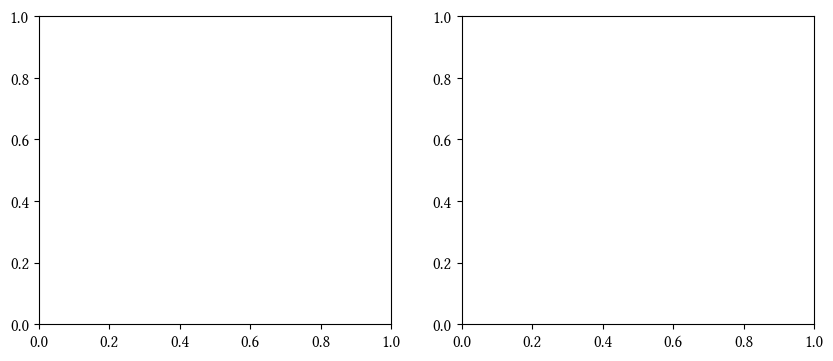

In [4]:
tmp_img = []
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, shap_map, title in zip(
        axes,
        [mean_shap_pd, mean_shap_hc],
        ["Mean |SHAP| , PD patients", "Mean |SHAP|: HC patients"]):
    if shap_map is None:
        ax.set_visible(False)
        continue
    print(f"shap_map has shape {shap_map.shape}")
    tmp = shap_map.mean(axis=2)            # (N, H, W)  avg channel for display
    tmp_img.append(tmp)

    #im = ax.imshow(shap_map, cmap="magma", interpolation="bilinear")
    im = ax.imshow(tmp, cmap="magma", interpolation="bilinear")
    ax.set_title(title, fontsize=11)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Average SHAP importance map\n(bright = model paid most attention here)", fontsize=12)
plt.tight_layout()
plt.show()
#out = os.path.join(CONFIG["output_dir"], "shap_mean_heatmap.svg")
#plt.savefig(out, dpi=160)
plt.close()
#print(f"Saved: {out}")

# plot the difference between both to see if the image is the same or not bcs it sure does feel like it
plt.tight_layout()
plt.imshow(tmp_img[1] - tmp_img[0], interpolation="bilinear", cmap="magma")
plt.title("Difference between HC mean and PD mean (HC - PD)", fontsize=11)
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()

# individual examples overlaid on image
def plot_shap_examples(indices, title, filename, n_show=6):
    n     = min(n_show, len(indices))
    if n == 0:
        return
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 5))

    for i, idx in enumerate(indices[:n]):
        img  = imgs_2d[idx]
        shap_map = shap_2d[idx]

        # Top row: raw image
        axes[0, i].imshow(img, cmap="gray")
        axes[0, i].set_title(f"Patient {idx}", fontsize=8)
        axes[0, i].axis("off")

        # Bottom row: SHAP heatmap overlaid
        axes[1, i].imshow(img, cmap="gray")
        axes[1, i].imshow(shap_map, cmap="RdBu_r", alpha=0.6,
                          vmin=-np.abs(shap_map).max(),
                          vmax= np.abs(shap_map).max())
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Input image", fontsize=9)
    axes[1, 0].set_ylabel("SHAP overlay\n(red=PD, blue=HC)", fontsize=9)
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    out = os.path.join(CONFIG["output_dir"], filename)
    plt.savefig(out, dpi=160)
    plt.close()
    print(f"Saved: {out}")


#plot_shap_examples(pd_idx, "SHAP examples, PD patients", "shap_examples_PD.svg")
#plot_shap_examples(hc_idx, "SHAP examples, HC patients", "shap_examples_HC.svg")


# try 3d

def plot_shap_3d(shap_vol_mean, filename, title):
    """
    shap_vol_mean: (H, W, D) mean |SHAP| across patients, 3D volume
    Shows central axial, coronal and sagittal slices.
    """
    H, W, D = shap_vol_mean.shape
    print(f'shape: {shap_vol_mean.shape}')
    
    #axial    = shap_vol_mean[:, :, D // 2]   # top-down
    #coronal  = shap_vol_mean[:, W // 2, :]   # front
    #sagittal = shap_vol_mean[H // 2, :, :]   # side
    axial     = shap_vol_mean.mean(axis = 2)
    coronal   = shap_vol_mean.mean(axis = 1)
    sagittal  = shap_vol_mean.mean(axis = 0)

    
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, sl, name in zip(axes,
                             [axial, coronal, sagittal],
                             ["Axial (top-down)", "Coronal (front)", "Sagittal (side)"]):
        im = ax.imshow(sl, cmap="magma", interpolation="bilinear")
        ax.set_title(name, fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    #plt.savefig(filename, dpi=160)
    plt.show()
    plt.close()

(76, 76, 76)
(76, 76, 76)
shape: (76, 76, 76)


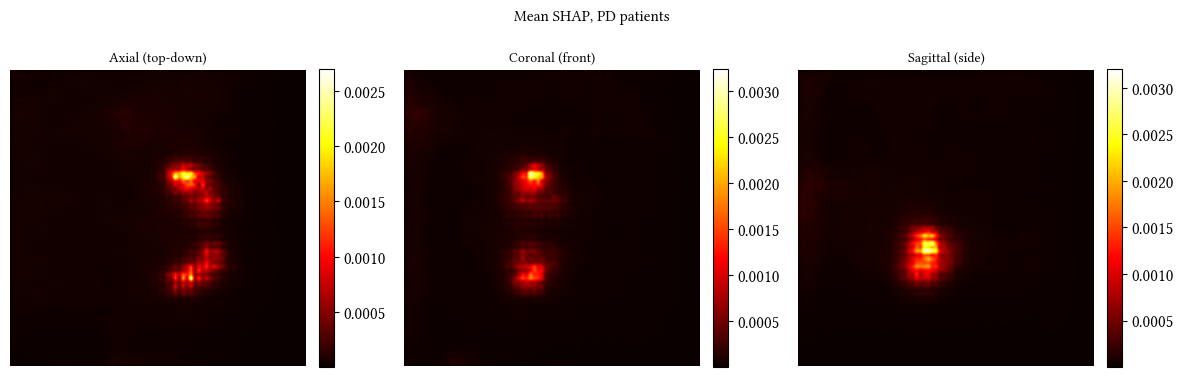

shape: (76, 76, 76)


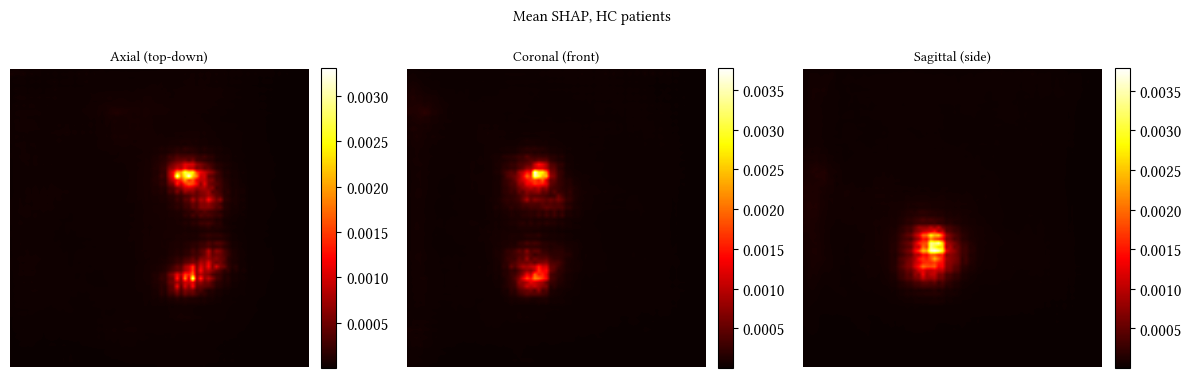


Done :)


In [ ]:
# shap_values shape: (N, 1, H, W, D)
shap_abs = np.abs(shap_values)  # (N, 1, H, W, D)

# Average over patients in each group first, then squeeze the channel dim
shap_pd = shap_abs[pd_idx].mean(axis=0).squeeze()  # (H, W, D)
shap_hc = shap_abs[hc_idx].mean(axis=0).squeeze()  # (H, W, D)

plot_shap_3d(shap_pd, "shap_3d_PD.svg", "Mean SHAP, PD patients")
plot_shap_3d(shap_hc, "shap_3d_HC.svg", "Mean SHAP, HC patients")

print("\nDone :)")

shape HC: (76, 76, 76)
shape PD: (76, 76, 76)


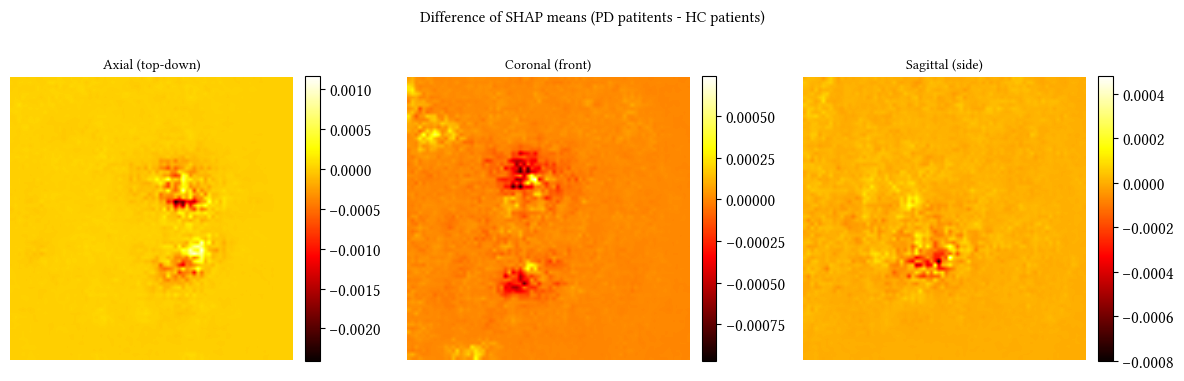

In [ ]:
# shap_values shape: (N, 1, H, W, D)
shap_abs = np.abs(shap_values)  # (N, 1, H, W, D)

# Average over patients in each group first, then squeeze the channel dim
shap_pd = shap_abs[pd_idx].mean(axis=0).squeeze()  # (H, W, D)
shap_hc = shap_abs[hc_idx].mean(axis=0).squeeze()  # (H, W, D)

def plot_shap_3d(shap_vol_mean_HC, shap_vol_mean_PD, filename, title):
    """
    shap_vol_mean: (H, W, D) mean |SHAP| across patients, 3D volume
    Shows central axial, coronal and sagittal slices.
    """
    H, W, D = shap_vol_mean_HC.shape
    print(f'shape HC: {shap_vol_mean_HC.shape}')
    axial_HC    = shap_vol_mean_HC[:, :, D // 2]   # top-down
    coronal_HC  = shap_vol_mean_HC[:, W // 2, :]   # front
    sagittal_HC = shap_vol_mean_HC[H // 2, :, :]   # side
    
    H, W, D = shap_vol_mean_PD.shape
    print(f'shape PD: {shap_vol_mean_PD.shape}')
    axial_PD    = shap_vol_mean_PD[:, :, D // 2]   # top-down
    coronal_PD  = shap_vol_mean_PD[:, W // 2, :]   # front
    sagittal_PD = shap_vol_mean_PD[H // 2, :, :]   # side

    axial    = axial_PD - axial_HC
    coronal  = coronal_PD - coronal_HC
    sagittal = sagittal_PD - sagittal_HC

 
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, sl, name in zip(axes,
                             [axial, coronal, sagittal],
                             ["Axial (top-down)", "Coronal (front)", "Sagittal (side)"]):
        im = ax.imshow(sl, cmap="hot", interpolation="bilinear")
        ax.set_title(name, fontsize=10)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    fig.suptitle(title, fontsize=11)
    plt.tight_layout()
    #plt.savefig(filename, dpi=160)
    plt.show()
    plt.close()

plot_shap_3d(shap_hc, shap_pd, "shap_3d_diff.svg", "Difference of SHAP means (PD patitents - HC patients)")